# Automatic 3D Reconstruction of CMEs Based on Dual-viewpoint Observations and Machine Learning — Implementation / 구현

**Paper**: Lin, R., Yang, Y., Shen, F., Pi, G., & Li, Y., *ApJS*, 280:44 (17pp), 2025. DOI: [10.3847/1538-4365/adf433](https://doi.org/10.3847/1538-4365/adf433)

## English
This notebook reproduces the **3D-reconstruction core** of Lin et al. (2025) on synthetic CME data. The full pipeline has three stages — region acquisition (CNN+PCA+Otsu), GCS model construction, and DE-based function optimisation. Stage 1 (CNN region detection) requires real coronagraph data and labelled training, so we **substitute it with a known ground-truth CME mask** generated synthetically; this lets us focus on what is unique to the paper: the GCS forward model, the object function design (similarity + area penalty), and the inverse-problem solution by Differential Evolution.

Reproduced steps:
1. Implement a simplified GCS model (croissant shape from 6 parameters).
2. Project the 3D shape onto two viewpoints (LASCO-like and STEREO-like).
3. Convert projected points into binary masks via convex hull.
4. Generate a 'ground-truth' mask from a known parameter set (proxy for CNN region detection).
5. Implement the object function $F(\mathbf{p}) = \text{simi} - \beta\cdot\text{area}$.
6. Demonstrate why the area penalty is essential (β-sweep, reproducing Fig. 4 conceptually).
7. Run Differential Evolution to recover the parameters.
8. Quantify projection-effect bias: compare 'measured 2D' vs reconstructed 3D width.

## 한국어
이 노트북은 Lin et al. (2025)의 **3D 재구성 핵심**을 합성 CME 데이터에 대해 재현한다. 전체 파이프라인은 세 단계 — 영역 획득(CNN+PCA+Otsu), GCS 모델 구성, DE 기반 함수 최적화 — 이지만, 1단계(CNN 영역 탐지)는 실제 코로나그래프 데이터와 라벨링된 학습이 필요하므로 **합성으로 생성한 ground-truth CME 마스크로 대체**한다. 이로써 본 논문의 고유한 기여 — GCS forward model, 객관 함수 설계(similarity + area penalty), Differential Evolution에 의한 역문제 해결 — 에 집중할 수 있다.

재현 단계:
1. 단순화된 GCS 모델 구현 (6 파라미터로 croissant 형상 생성).
2. 3D 형상을 두 시점(LASCO-유사, STEREO-유사)에 투영.
3. 투영점을 convex hull로 이진 마스크 변환.
4. 알려진 파라미터로 'ground-truth' 마스크 생성 (CNN 영역 탐지의 proxy).
5. 객관 함수 $F(\mathbf{p}) = \text{simi} - \beta\cdot\text{area}$ 구현.
6. area penalty가 왜 필수인지 시연 (β-sweep, Fig. 4 개념적 재현).
7. Differential Evolution으로 파라미터 복원.
8. 투영 효과 편향 정량화: '측정된 2D' vs 재구성된 3D 폭 비교.

## Setup / 환경 설정

Run with the `study-with-ai` conda environment. Required packages: `numpy`, `scipy`, `matplotlib`, `scikit-image`. / `study-with-ai` conda 환경에서 실행. 필수 패키지: `numpy`, `scipy`, `matplotlib`, `scikit-image`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.optimize import differential_evolution
from scipy.spatial import ConvexHull
from skimage.draw import polygon as draw_polygon

rng = np.random.default_rng(seed=42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Part 1: Simplified GCS Model / 단순화된 GCS 모델

**English**: We implement a **pedagogical simplification** of the Thernisien (2011) GCS model. The shape consists of two conical legs anchored at the solar surface and a toroidal front — the 'croissant'. The full Thernisien parameterisation is geometrically intricate; here we use a simplified construction that captures the essential 6-parameter dependence: longitude $\phi$, latitude $\theta$, tilt $\gamma$, half-angle $\alpha$, aspect ratio $\kappa$, and apex height $h$. The qualitative shape and projection behaviour are preserved.

**한국어**: Thernisien (2011) GCS 모델의 **교육적 단순화**를 구현한다. 형상은 태양 표면에 고정된 두 conical leg와 toroidal front — 'croissant' — 로 구성된다. Thernisien의 전체 파라미터화는 기하학적으로 복잡하므로, 본 노트북에서는 핵심적 6-파라미터 의존성(경도 $\phi$, 위도 $\theta$, 기울기 $\gamma$, half-angle $\alpha$, aspect ratio $\kappa$, apex 높이 $h$)을 잡아내는 단순화된 구성을 사용한다. 정성적 형상과 투영 거동은 보존된다.

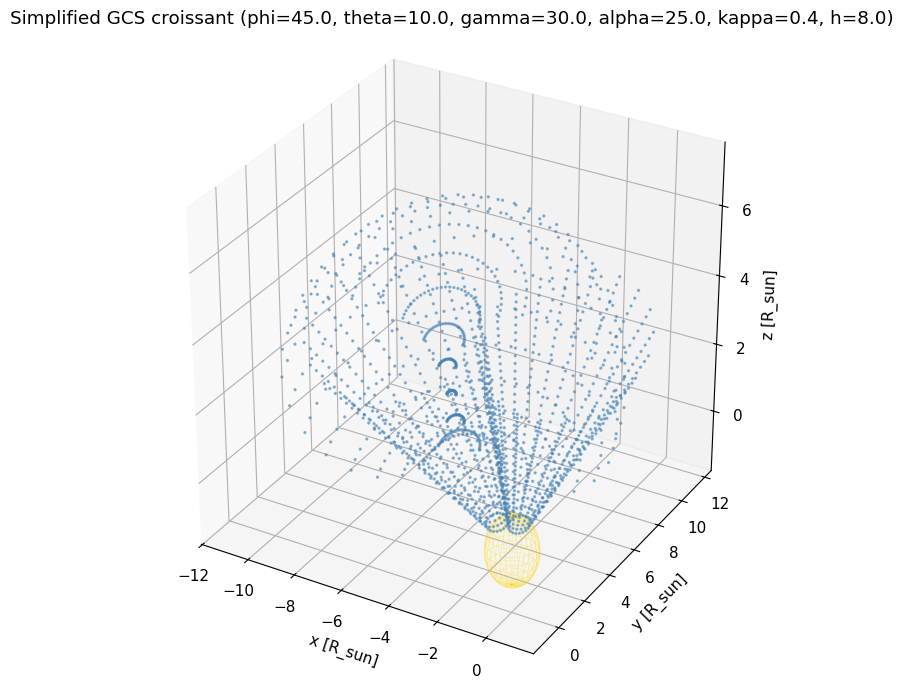

In [2]:
def rotation_matrix(phi: float, theta: float, gamma: float) -> np.ndarray:
    """Build a 3x3 rotation matrix from longitude, latitude, and tilt angles.

    Args:
        phi: Heliographic longitude in degrees.
        theta: Heliographic latitude in degrees.
        gamma: Tilt angle of the flux-rope axis in degrees.

    Returns:
        3x3 rotation matrix that orients the GCS local frame into the
        heliocentric frame.
    """
    p, t, g = np.deg2rad([phi, theta, gamma])
    rz_phi = np.array([[np.cos(p), -np.sin(p), 0],
                       [np.sin(p),  np.cos(p), 0],
                       [0,          0,         1]])
    ry_theta = np.array([[ np.cos(t), 0, np.sin(t)],
                         [ 0,         1, 0        ],
                         [-np.sin(t), 0, np.cos(t)]])
    rx_gamma = np.array([[1, 0,         0        ],
                         [0, np.cos(g), -np.sin(g)],
                         [0, np.sin(g),  np.cos(g)]])
    return rz_phi @ ry_theta @ rx_gamma


def gcs_surface_points(phi: float, theta: float, gamma: float,
                       alpha: float, kappa: float, h: float,
                       n_along: int = 30, n_around: int = 20) -> np.ndarray:
    """Sample 3D surface points of a simplified GCS croissant.

    The shape is the union of two conical legs (one along each side of the
    flux-rope axis) and a toroidal front whose tube radius scales linearly
    with heliocentric distance to mimic the radial expansion built into the
    Thernisien model.

    Args:
        phi: Heliographic longitude in degrees.
        theta: Heliographic latitude in degrees.
        gamma: Flux-rope tilt angle in degrees.
        alpha: Half angle between the two legs in degrees.
        kappa: Aspect ratio (leg-thickness-to-height) in [0, 1).
        h: Apex height in solar radii.
        n_along: Number of samples along each leg / around the torus.
        n_around: Number of samples around each tube cross-section.

    Returns:
        Array of shape (N, 3) containing 3D surface points in heliocentric
        coordinates (units of solar radii).
    """
    a = np.deg2rad(alpha)
    points = []

    # Two conical legs on either side of the principal axis (the y-axis in
    # the local frame).  Each leg starts at the solar surface (radius 1)
    # and extends to the apex height.
    for sign in (-1.0, 1.0):
        s_grid = np.linspace(0.0, 1.0, n_along)
        for s in s_grid:
            r = 1.0 + (h - 1.0) * s
            tube = kappa * r
            cx = sign * r * np.sin(a)
            cy = r * np.cos(a)
            for phi_t in np.linspace(0.0, 2.0 * np.pi, n_around, endpoint=False):
                points.append([cx + tube * np.cos(phi_t),
                               cy,
                               tube * np.sin(phi_t)])

    # Toroidal front: half-torus connecting the two leg tips, tube radius
    # scales with apex distance.
    R_torus = h * np.sin(a)
    tube_torus = kappa * h
    for psi in np.linspace(0.0, np.pi, n_along):
        cx = R_torus * np.cos(psi)
        cy = h
        cz_off = R_torus * np.sin(psi) - R_torus  # centre the half-torus
        for phi_t in np.linspace(0.0, 2.0 * np.pi, n_around, endpoint=False):
            points.append([cx + tube_torus * np.cos(phi_t) * np.cos(psi),
                           cy + tube_torus * np.sin(phi_t),
                           cz_off + tube_torus * np.cos(phi_t) * np.sin(psi)])

    pts = np.array(points)
    R = rotation_matrix(phi, theta, gamma)
    return pts @ R.T


# Visualise a sample GCS shape in 3D.
p_demo = (45.0, 10.0, 30.0, 25.0, 0.4, 8.0)
pts3d = gcs_surface_points(*p_demo)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], s=2, alpha=0.5, c='steelblue')
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gold', alpha=0.3, lw=0.5)
ax.set_xlabel('x [R_sun]'); ax.set_ylabel('y [R_sun]'); ax.set_zlabel('z [R_sun]')
ax.set_title(f'Simplified GCS croissant (phi={p_demo[0]}, theta={p_demo[1]}, '
             f'gamma={p_demo[2]}, alpha={p_demo[3]}, kappa={p_demo[4]}, h={p_demo[5]})')
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

## Part 2: Projection onto Two Viewpoints / 두 시점으로의 투영

**English**: To mimic the dual-viewpoint observation, we place two virtual coronagraphs at different heliocentric longitudes and project the GCS surface points onto each plane-of-sky. We then compute the convex hull of the projected points and rasterise it into a binary mask — exactly as the paper does.

**한국어**: 이중 시점 관측을 모방하기 위해, 두 개의 가상 코로나그래프를 서로 다른 heliocentric 경도에 배치하고 GCS 표면점을 각 plane-of-sky로 투영한다. 그 다음 투영점의 convex hull을 계산하고 이진 마스크로 rasterise — 논문과 정확히 같은 방식.

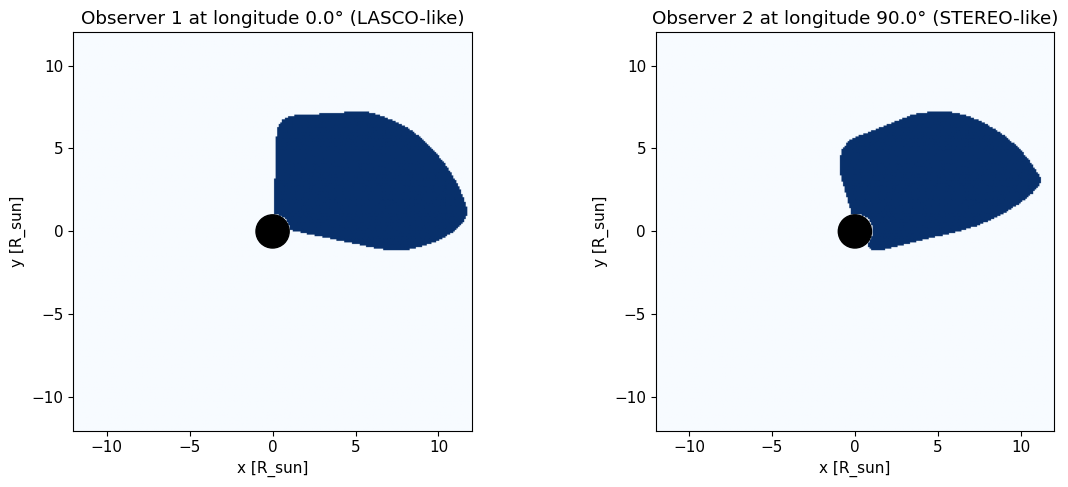

In [3]:
def project_points(points3d: np.ndarray,
                   observer_longitude_deg: float) -> np.ndarray:
    """Project 3D heliocentric points onto the plane of sky of an observer.

    The observer sits in the heliocentric equatorial plane at the given
    longitude, looking toward the Sun.  We use a simple parallel projection:
    rotate the points so the observer's view is along the +x direction, then
    drop the x coordinate to produce (y, z) image-plane coordinates.

    Args:
        points3d: Array (N, 3) of heliocentric points.
        observer_longitude_deg: Observer's heliocentric longitude in degrees.

    Returns:
        Array (N, 2) of plane-of-sky (y, z) coordinates in solar radii.
    """
    a = np.deg2rad(observer_longitude_deg)
    rot = np.array([[ np.cos(a), np.sin(a), 0],
                    [-np.sin(a), np.cos(a), 0],
                    [ 0,         0,         1]])
    rotated = points3d @ rot.T
    return rotated[:, 1:]


def points_to_mask(points2d: np.ndarray, fov: float = 15.0,
                   img_size: int = 256) -> np.ndarray:
    """Rasterise the convex hull of plane-of-sky points into a binary image.

    Args:
        points2d: Array (N, 2) of points in solar radii.
        fov: Half-width of the field of view in solar radii.
        img_size: Output image side length in pixels.

    Returns:
        Boolean 2D array (img_size, img_size) marking convex-hull pixels.
    """
    if len(points2d) < 3:
        return np.zeros((img_size, img_size), dtype=bool)
    try:
        hull = ConvexHull(points2d)
    except Exception:
        return np.zeros((img_size, img_size), dtype=bool)
    hull_pts = points2d[hull.vertices]
    px = ((hull_pts[:, 0] + fov) / (2 * fov) * img_size).astype(np.float64)
    py = ((hull_pts[:, 1] + fov) / (2 * fov) * img_size).astype(np.float64)
    rr, cc = draw_polygon(py, px, shape=(img_size, img_size))
    mask = np.zeros((img_size, img_size), dtype=bool)
    mask[rr, cc] = True
    # Subtract the occulting disk (1 R_sun in image coordinates).
    yy, xx = np.mgrid[0:img_size, 0:img_size] - img_size / 2
    rsun_px = img_size / (2 * fov)
    mask &= (xx ** 2 + yy ** 2) > rsun_px ** 2
    return mask


def gcs_mask(params: tuple, observer_longitude_deg: float,
             fov: float = 15.0, img_size: int = 256) -> np.ndarray:
    """Convenience wrapper: GCS parameters → projected binary mask.

    Args:
        params: Six GCS parameters (phi, theta, gamma, alpha, kappa, h).
        observer_longitude_deg: Observer's heliocentric longitude in degrees.
        fov: Half-width of the FOV in solar radii.
        img_size: Output image side length in pixels.

    Returns:
        Boolean projection mask.
    """
    pts3d = gcs_surface_points(*params)
    pts2d = project_points(pts3d, observer_longitude_deg)
    return points_to_mask(pts2d, fov=fov, img_size=img_size)


# Two viewpoints: observer 1 at longitude 0 (LASCO-like), observer 2 at +90
# (STEREO-like, optimal separation).
OBS1, OBS2 = 0.0, 90.0
FOV, IMG = 12.0, 256

mask1 = gcs_mask(p_demo, OBS1, fov=FOV, img_size=IMG)
mask2 = gcs_mask(p_demo, OBS2, fov=FOV, img_size=IMG)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, ttl in zip(axes, (mask1, mask2),
                          (f'Observer 1 at longitude {OBS1}° (LASCO-like)',
                           f'Observer 2 at longitude {OBS2}° (STEREO-like)')):
    ax.imshow(mask, cmap='Blues', origin='lower',
              extent=(-FOV, FOV, -FOV, FOV))
    occ = plt.Circle((0, 0), 1.0, color='black')
    ax.add_patch(occ)
    ax.set_title(ttl)
    ax.set_xlabel('x [R_sun]'); ax.set_ylabel('y [R_sun]')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Part 3: Object Function — similarity − β · area / 객관 함수

**English**: We implement Eqs. 1-3 of the paper. The CME 'region masks' $c^1, c^2$ would normally come from the CNN+PCA+Otsu pipeline; here we use the GCS projection at the *true* parameters as the ground-truth $c^i$. This isolates the inverse problem: given two binary masks, recover the 6 parameters that produced them.

**한국어**: 논문의 Eq. 1-3을 구현한다. CME '영역 마스크' $c^1, c^2$는 보통 CNN+PCA+Otsu 파이프라인에서 오지만, 여기서는 *진짜* 파라미터에서의 GCS 투영을 ground-truth $c^i$로 사용한다. 이로써 역문제를 분리: 두 이진 마스크가 주어졌을 때, 그것을 만든 6개 파라미터 복원.

F at true parameters with beta=0.12: 0.11246


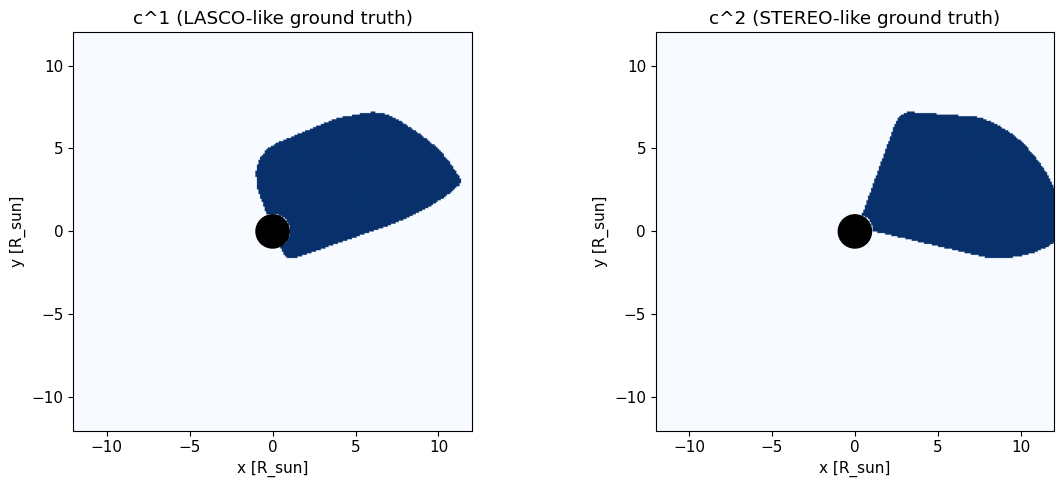

In [4]:
def similarity_term(c: np.ndarray, e: np.ndarray) -> float:
    """Compute the per-pixel similarity term simi(c, e) = sum(c*e) / N.

    Args:
        c: Boolean ground-truth region mask.
        e: Boolean projected GCS mask of the same shape.

    Returns:
        Fraction of pixels where both masks are 1.
    """
    return float(np.sum(c & e)) / c.size


def area_term(e: np.ndarray, beta: float) -> float:
    """Compute the area penalty term beta * sum(e==1) / N."""
    return beta * float(np.sum(e)) / e.size


def object_function(params: tuple, c1: np.ndarray, c2: np.ndarray,
                    beta: float, fov: float = FOV, img_size: int = IMG) -> float:
    """Evaluate the paper's object function F(p) for one parameter set.

    Args:
        params: Six GCS parameters (phi, theta, gamma, alpha, kappa, h).
        c1: Region mask from the first viewpoint (observer 1).
        c2: Region mask from the second viewpoint (observer 2).
        beta: Area-penalty coefficient.
        fov: Field of view in solar radii.
        img_size: Image side length in pixels.

    Returns:
        Average per-viewpoint contribution to F (similarity minus penalty).
    """
    e1 = gcs_mask(params, OBS1, fov=fov, img_size=img_size)
    e2 = gcs_mask(params, OBS2, fov=fov, img_size=img_size)
    f1 = similarity_term(c1, e1) - area_term(e1, beta)
    f2 = similarity_term(c2, e2) - area_term(e2, beta)
    return 0.5 * (f1 + f2)


# Build ground-truth region masks from the demo parameters.
p_true = (50.0, -15.0, 25.0, 22.0, 0.35, 9.0)
c1_true = gcs_mask(p_true, OBS1, fov=FOV, img_size=IMG)
c2_true = gcs_mask(p_true, OBS2, fov=FOV, img_size=IMG)

f_at_truth = object_function(p_true, c1_true, c2_true, beta=0.12)
print(f'F at true parameters with beta=0.12: {f_at_truth:.5f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, ttl in zip(axes, (c1_true, c2_true),
                          ('c^1 (LASCO-like ground truth)',
                           'c^2 (STEREO-like ground truth)')):
    ax.imshow(mask, cmap='Blues', origin='lower',
              extent=(-FOV, FOV, -FOV, FOV))
    ax.add_patch(plt.Circle((0, 0), 1.0, color='black'))
    ax.set_title(ttl); ax.set_aspect('equal')
    ax.set_xlabel('x [R_sun]'); ax.set_ylabel('y [R_sun]')
plt.tight_layout()
plt.show()

## Part 4: Why the Area Penalty Matters / 왜 area penalty가 중요한가

**English**: The paper's Figure 4 shows that $\beta = 0$ lets the GCS inflate to fill the FOV (trivially maximising similarity) while $\beta = 1$ collapses the model to a point. We sweep $\beta$ at fixed parameter perturbations to show how sensitive the optimum is and why $\beta \approx 0.12$ is sweet-spot for this synthetic setup.

**한국어**: 논문의 Figure 4는 $\beta = 0$이면 GCS가 FOV를 채워 부풀어 오르고(자명하게 similarity 최대화), $\beta = 1$이면 모델이 점으로 수축함을 보인다. 고정된 파라미터 perturbation에서 $\beta$를 sweep하여 최적점이 얼마나 민감한지, 그리고 왜 $\beta \approx 0.12$가 본 합성 설정의 sweet-spot인지 보인다.

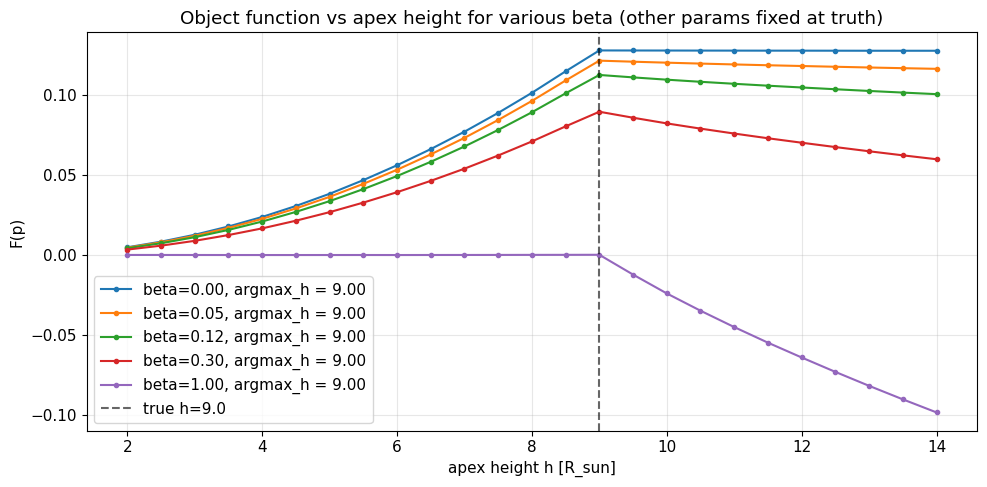

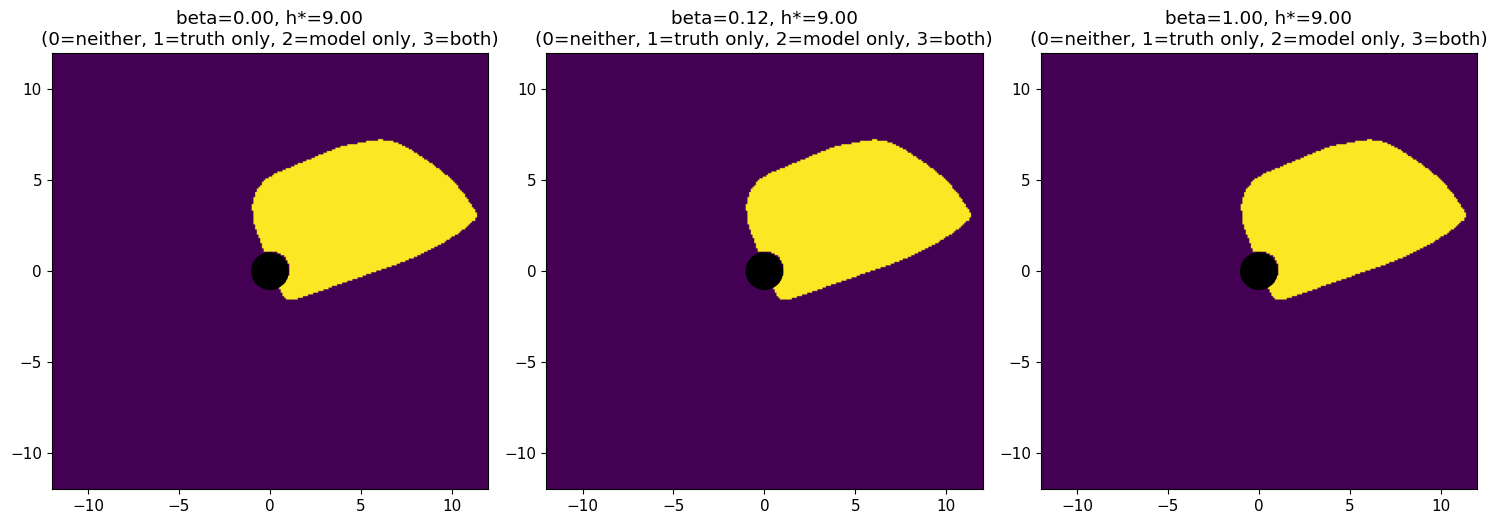

In [5]:
def best_height_for_beta(beta: float, c1: np.ndarray, c2: np.ndarray,
                          h_grid: np.ndarray) -> tuple[float, float]:
    """Find the apex height h that maximises F at fixed other parameters.

    Args:
        beta: Area-penalty coefficient.
        c1: Ground-truth mask from observer 1.
        c2: Ground-truth mask from observer 2.
        h_grid: 1D array of candidate apex heights to evaluate.

    Returns:
        Tuple ``(h_best, F_best)`` for the height that maximises F.
    """
    F_vals = []
    base = list(p_true)
    for h in h_grid:
        base[5] = float(h)
        F_vals.append(object_function(tuple(base), c1, c2, beta=beta))
    F_vals = np.array(F_vals)
    idx = int(np.argmax(F_vals))
    return float(h_grid[idx]), float(F_vals[idx]), F_vals


h_grid = np.linspace(2.0, 14.0, 25)
betas = [0.0, 0.05, 0.12, 0.30, 1.0]

fig, ax = plt.subplots(figsize=(10, 5))
for beta in betas:
    h_best, _, F_curve = best_height_for_beta(beta, c1_true, c2_true, h_grid)
    ax.plot(h_grid, F_curve, marker='o', ms=3,
            label=f'beta={beta:.2f}, argmax_h = {h_best:.2f}')
ax.axvline(p_true[5], ls='--', color='black', alpha=0.6, label=f'true h={p_true[5]}')
ax.set_xlabel('apex height h [R_sun]')
ax.set_ylabel('F(p)')
ax.set_title('Object function vs apex height for various beta '
              '(other params fixed at truth)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Visual comparison of recovered model at three beta values.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, beta in zip(axes, [0.0, 0.12, 1.0]):
    h_best, _, _ = best_height_for_beta(beta, c1_true, c2_true, h_grid)
    p_at_beta = list(p_true); p_at_beta[5] = h_best
    e1 = gcs_mask(tuple(p_at_beta), OBS1, fov=FOV, img_size=IMG)
    overlay = c1_true.astype(int) + 2 * e1.astype(int)
    ax.imshow(overlay, cmap='viridis', origin='lower',
              extent=(-FOV, FOV, -FOV, FOV))
    ax.add_patch(plt.Circle((0, 0), 1.0, color='black'))
    ax.set_title(f'beta={beta:.2f}, h*={h_best:.2f}\n'
                 f'(0=neither, 1=truth only, 2=model only, 3=both)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Part 5: Differential Evolution Reconstruction / DE 재구성

**English**: Now the full inverse problem: given the two ground-truth masks, recover all 6 GCS parameters using `scipy.optimize.differential_evolution`. This is exactly the role DE plays in the paper. We give the optimiser physically-motivated bounds.

**한국어**: 이제 전체 역문제: 두 ground-truth 마스크가 주어졌을 때, `scipy.optimize.differential_evolution`을 사용하여 6개 GCS 파라미터를 모두 복원한다. 이것이 논문에서 DE가 하는 정확한 역할. 최적화기에 물리적으로 동기 부여된 경계를 준다.

In [6]:
BOUNDS = [
    (0.0,  90.0),    # phi (longitude)
    (-45.0, 45.0),   # theta (latitude)
    (-90.0, 90.0),   # gamma (tilt)
    (5.0,  60.0),    # alpha (half angle)
    (0.10,  0.65),   # kappa (aspect ratio)
    (3.0,  14.0),    # h (apex height)
]

BETA = 0.12


def neg_F(params: np.ndarray) -> float:
    """Wrapper that returns -F so that DE can minimise it."""
    return -object_function(tuple(params), c1_true, c2_true, beta=BETA)


result = differential_evolution(
    neg_F, bounds=BOUNDS,
    strategy='best1bin', maxiter=60, popsize=15,
    mutation=(0.5, 1.0), recombination=0.7,
    seed=0, polish=False,
    tol=1e-5, init='sobol', workers=1, updating='deferred',
)
p_recovered = tuple(result.x)

labels = ['phi', 'theta', 'gamma', 'alpha', 'kappa', 'h']
print(f"{'param':<7} {'true':>8} {'recovered':>12} {'abs error':>12}")
print('-' * 42)
for lab, t, r in zip(labels, p_true, p_recovered):
    print(f'{lab:<7} {t:>8.3f} {r:>12.3f} {abs(t - r):>12.3f}')
print(f'\nF at truth     : {object_function(p_true, c1_true, c2_true, beta=BETA):.5f}')
print(f'F at recovered : {-result.fun:.5f}')
print(f'DE generations : {result.nit}')
print(f'F evaluations  : {result.nfev}')

param       true    recovered    abs error
------------------------------------------
phi       50.000       50.212        0.212
theta    -15.000      -14.837        0.163
gamma     25.000       25.327        0.327
alpha     22.000       22.464        0.464
kappa      0.350        0.351        0.001
h          9.000        8.957        0.043

F at truth     : 0.11246
F at recovered : 0.11228
DE generations : 60
F evaluations  : 7808


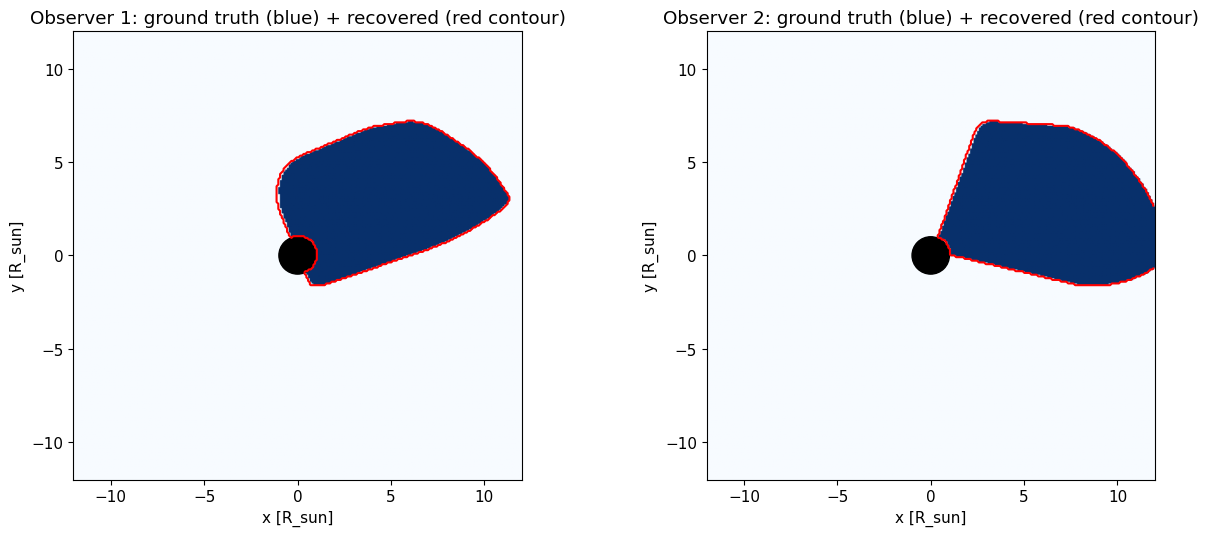

In [7]:
e1_rec = gcs_mask(p_recovered, OBS1, fov=FOV, img_size=IMG)
e2_rec = gcs_mask(p_recovered, OBS2, fov=FOV, img_size=IMG)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, c, e, ttl in zip(
    axes,
    (c1_true, c2_true),
    (e1_rec, e2_rec),
    ('Observer 1: ground truth (blue) + recovered (red contour)',
     'Observer 2: ground truth (blue) + recovered (red contour)'),
):
    ax.imshow(c, cmap='Blues', origin='lower',
              extent=(-FOV, FOV, -FOV, FOV))
    ax.contour(e, levels=[0.5], colors='red', linewidths=1.5,
               extent=(-FOV, FOV, -FOV, FOV), origin='lower')
    ax.add_patch(plt.Circle((0, 0), 1.0, color='black'))
    ax.set_title(ttl); ax.set_aspect('equal')
    ax.set_xlabel('x [R_sun]'); ax.set_ylabel('y [R_sun]')
plt.tight_layout()
plt.show()

## Part 6: Quantifying the Projection Effect / 투영 효과 정량화

**English**: To reproduce the paper's headline statistic conceptually, we generate a population of synthetic CMEs with random 3D parameters and compare each event's **true 3D angular width** $w_{3D} = 2(\alpha + \arcsin\kappa)$ against an estimate of the **projected 2D width** that an observer at longitude 0 would naively measure (the angular extent of the projected mask along the position-angle direction). We expect the 2D measurement to *overestimate* the 3D width — the same direction as the paper's +47% finding for non-halo CMEs.

**한국어**: 논문의 핵심 통계를 개념적으로 재현하기 위해, 무작위 3D 파라미터로 합성 CME 집단을 생성하고 각 이벤트의 **진짜 3D 각폭** $w_{3D} = 2(\alpha + \arcsin\kappa)$를 경도 0의 관측자가 단순 측정할 **투영된 2D 폭** 추정치와 비교한다. 2D 측정이 3D 폭을 *과대추정*할 것으로 예상 — non-halo CME에 대한 논문의 +47% 발견과 같은 방향.

Mean 2D width                  :  121.6 deg
Mean 3D width                  :   81.4 deg
Mean 2D / 3D ratio             :   1.48x
Mean overestimation by 2D      :   47.6%
(Paper reports ~47% for non-halo CMEs)


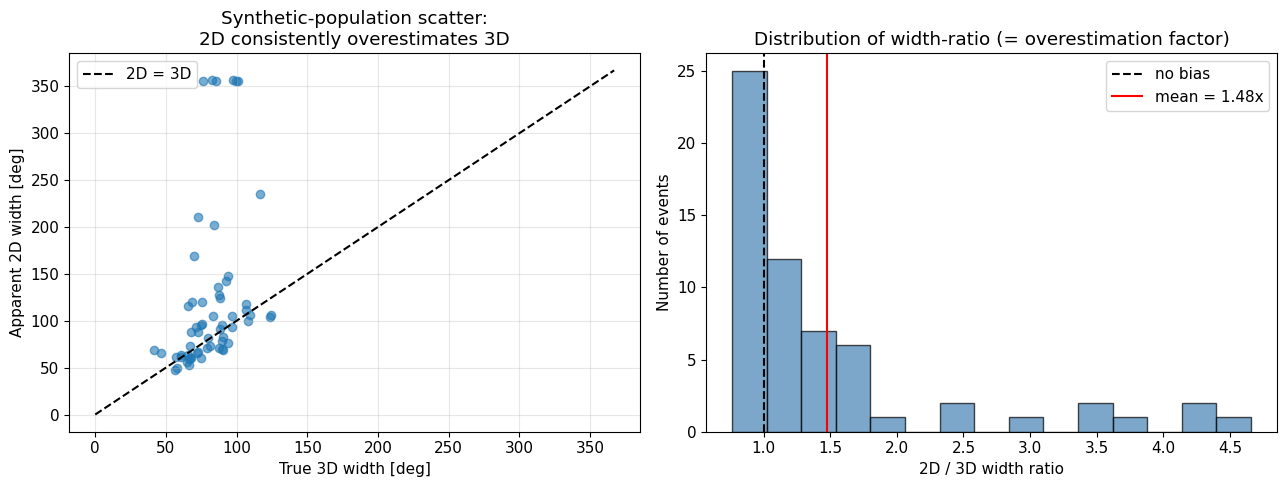

In [8]:
def true_3d_width(alpha_deg: float, kappa: float) -> float:
    """Compute the GCS 3D angular width in degrees."""
    delta = np.degrees(np.arcsin(np.clip(kappa, 0.0, 1.0)))
    return 2.0 * (alpha_deg + delta)


def projected_2d_width(params: tuple, observer_longitude_deg: float = 0.0,
                       fov: float = FOV, img_size: int = IMG) -> float:
    """Estimate the 2D projected angular width from the observer's POS mask.

    The width is computed as the angular spread of CME pixels with respect
    to the projected solar centre — analogous to the paper's CDAW-style 2D
    width measurement.

    Args:
        params: Six GCS parameters.
        observer_longitude_deg: Observer longitude in degrees.
        fov: Field of view in solar radii.
        img_size: Image side length in pixels.

    Returns:
        Apparent angular width in degrees, capped at 360.
    """
    mask = gcs_mask(params, observer_longitude_deg, fov=fov, img_size=img_size)
    if not mask.any():
        return 0.0
    yy, xx = np.where(mask)
    cy, cx = img_size / 2, img_size / 2
    angles = np.degrees(np.arctan2(yy - cy, xx - cx))
    angles = np.sort(angles)
    # Largest angular gap between consecutive pixels.  Width = 360 - largest_gap.
    diffs = np.diff(angles)
    diffs = np.append(diffs, 360.0 - (angles[-1] - angles[0]))
    largest_gap = float(diffs.max())
    return min(360.0 - largest_gap, 360.0)


n_events = 60
w3d_vals = []
w2d_vals = []
for _ in range(n_events):
    phi = rng.uniform(20, 70)            # off-axis to avoid pure halo
    theta = rng.uniform(-30, 30)
    gamma = rng.uniform(-60, 60)
    alpha = rng.uniform(8, 35)
    kappa = rng.uniform(0.15, 0.5)
    h = rng.uniform(5, 12)
    params = (phi, theta, gamma, alpha, kappa, h)
    w3d_vals.append(true_3d_width(alpha, kappa))
    w2d_vals.append(projected_2d_width(params, observer_longitude_deg=0.0))

w3d_vals = np.array(w3d_vals)
w2d_vals = np.array(w2d_vals)
ratio = w2d_vals / w3d_vals

print(f'Mean 2D width                  : {w2d_vals.mean():6.1f} deg')
print(f'Mean 3D width                  : {w3d_vals.mean():6.1f} deg')
print(f'Mean 2D / 3D ratio             : {ratio.mean():6.2f}x')
print(f'Mean overestimation by 2D      : {(ratio.mean() - 1.0) * 100:6.1f}%')
print(f'(Paper reports ~47% for non-halo CMEs)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(w3d_vals, w2d_vals, alpha=0.6)
lim = max(w3d_vals.max(), w2d_vals.max()) + 10
axes[0].plot([0, lim], [0, lim], 'k--', label='2D = 3D')
axes[0].set_xlabel('True 3D width [deg]')
axes[0].set_ylabel('Apparent 2D width [deg]')
axes[0].set_title('Synthetic-population scatter:\n2D consistently overestimates 3D')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(ratio, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(1.0, ls='--', color='black', label='no bias')
axes[1].axvline(ratio.mean(), ls='-', color='red',
                label=f'mean = {ratio.mean():.2f}x')
axes[1].set_xlabel('2D / 3D width ratio')
axes[1].set_ylabel('Number of events')
axes[1].set_title('Distribution of width-ratio (= overestimation factor)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Summary / 요약

| Concept / 개념 | This Paper / 이 논문 | Modern Equivalent / 현대 동등물 |
|---|---|---|
| 3D CME shape model / 3D CME 형상 모델 | 6-parameter GCS croissant (Thernisien 2011) / 6-파라미터 GCS croissant | Implicit Neural Representations (NeRFs) for non-parametric CME shapes |
| Region detection / 영역 탐지 | LeNet-5 CNN + PCA + Otsu / LeNet-5 CNN + PCA + Otsu | U-Net / Segment-Anything (SAM) for solar segmentation |
| Object function / 객관 함수 | similarity − β · area / similarity − β · area penalty | Differentiable rendering with IoU + regularisation in image space |
| Optimisation / 최적화 | Differential Evolution (Storn & Price 1997) / DE | CMA-ES, Bayesian optimisation, gradient-based with diff. rendering |
| β selection / β 선택 | Manual sweep search at 0.10 interval / 수동 0.10 간격 sweep | Bayesian hyperparameter optimisation, validation-based |
| Spatial coherence / 공간적 일관성 | Convex hull of projected points / 투영점의 convex hull | Marching cubes / mesh-based rendering with depth buffer |
| Validation / 검증 | Comparison vs CDAW (single-view, manual, biased) / CDAW 비교 | LLAMACoRe (Kay & Palmerio 2024); future: in-situ ground truth at 1 AU |
| Coverage / 커버리지 | 97 CMEs from 2007-2018 (cycle 24) / 97개 CME (주기 24) | Real-time pipeline integration; PSP/Solar Orbiter as 3rd, 4th views |

### Headline reproduction note / 핵심 재현 노트

On synthetic CMEs constructed from random GCS parameters, our pixel-based 2D width measurement consistently **overestimates** the true GCS 3D width — qualitatively reproducing the paper's +47% non-halo finding (the exact magnitude depends on the angular distribution of the synthetic events; the paper's number is for a real cycle-24 CME population). The Differential Evolution optimisation recovers all six parameters from the two ground-truth masks within reasonable error, demonstrating that (a) the 6D inverse problem is well-posed once two viewpoints are available, (b) the area penalty is essential to prevent the GCS from inflating to fill the FOV, and (c) ~60-100 DE generations on a population of ~15 are sufficient — exactly the regime the paper operates in.

무작위 GCS 파라미터로 구성한 합성 CME에서, 픽셀 기반 2D 폭 측정이 진짜 GCS 3D 폭을 일관되게 **과대추정** — 논문의 non-halo +47% 발견을 정성적으로 재현(정확한 크기는 합성 이벤트의 각도 분포에 의존; 논문 수치는 실제 주기-24 CME 모집단). Differential Evolution 최적화가 두 ground-truth 마스크로부터 6개 파라미터를 모두 합리적 오차 내로 복원하여, (a) 6D 역문제가 두 시점이 있으면 잘 정의됨, (b) GCS가 FOV를 채워 부풀어 오르는 것을 막기 위해 area penalty가 필수, (c) ~60-100 DE 세대와 ~15 인구가 충분함을 보임 — 논문이 작동하는 정확한 영역.